In [27]:
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [ ]:
DATASET_DIR = "../datasets/openwebtext-100k"
MODEl_DIR = "../models/Qwen2.5-0.5B"
MAX_SEQ_LEN = 1024

In [ ]:
dataset = load_dataset(path=DATASET_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEl_DIR)

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [13]:
display(dataset)
print("-" * 100)
print(dataset["train"][0]["text"][:500])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 100000
    })
})

----------------------------------------------------------------------------------------------------
Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.

The decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.

CNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the B


In [22]:
def add_num_tokens(batch):
    tokenized = tokenizer(batch["text"], truncation=False, padding=False)
    batch["num_tokens"] = [len(ids) for ids in tokenized["input_ids"]]
    return batch

In [24]:
dataset = dataset.map(add_num_tokens, batched=True, num_proc=8)

Map (num_proc=8):   0%|          | 0/100000 [00:00<?, ? examples/s]

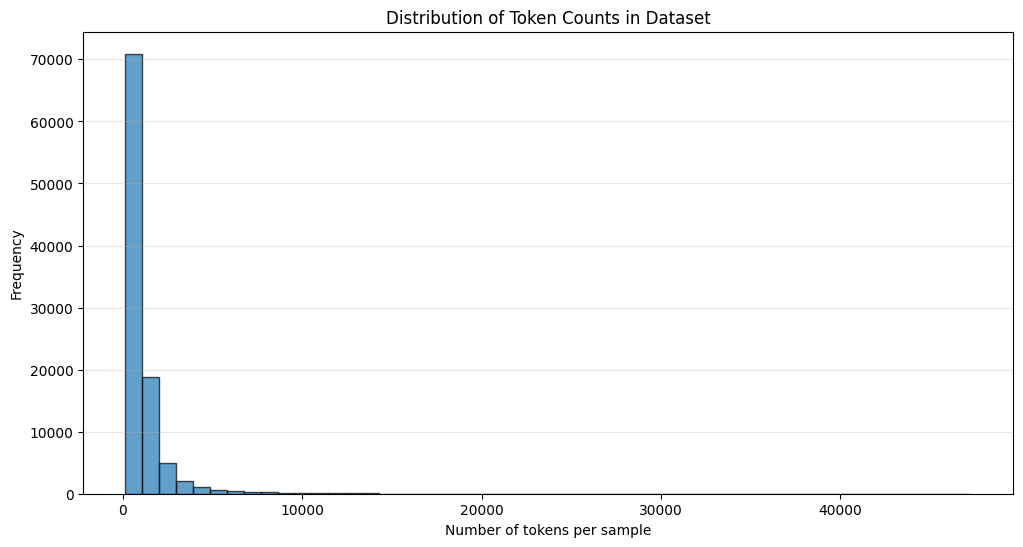

In [28]:
token_counts = dataset["train"]["num_tokens"]

plt.figure(figsize=(12, 6))
plt.hist(token_counts, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Number of tokens per sample")
plt.ylabel("Frequency")
plt.title("Distribution of Token Counts in Dataset")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [34]:
filtered_dataset = dataset.filter(lambda x: x["num_tokens"] <= MAX_SEQ_LEN)

print(f"Original samples: {len(dataset['train'])}")
print(
    f"Samples after filtering (num_tokens <= {MAX_SEQ_LEN}): {len(filtered_dataset['train'])}"
)
print(f"Dropped samples: {len(dataset['train']) - len(filtered_dataset['train'])}")

Filter:   0%|          | 0/100000 [00:00<?, ? examples/s]

Original samples: 100000
Samples after filtering (num_tokens <= 1024): 68637
Dropped samples: 31363


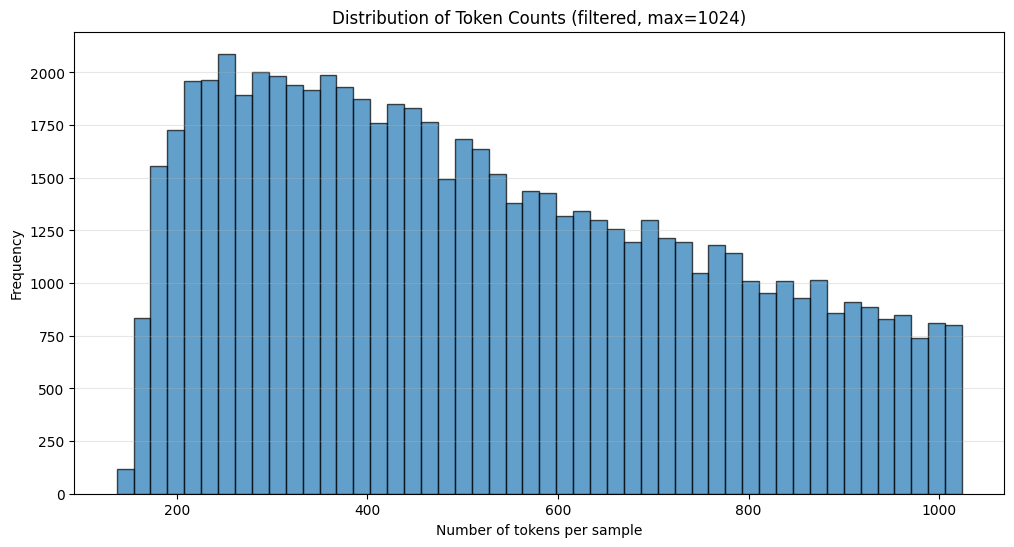

In [35]:
token_counts_filtered = filtered_dataset["train"]["num_tokens"]

plt.figure(figsize=(12, 6))
plt.hist(token_counts_filtered, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Number of tokens per sample")
plt.ylabel("Frequency")
plt.title(f"Distribution of Token Counts (filtered, max={MAX_SEQ_LEN})")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [38]:
N_SAMPLES = len(filtered_dataset["train"]) // 1000
save_path = f"../datasets/prepared_openwebtext-{N_SAMPLES}k.parquet"
filtered_dataset["train"].to_parquet(save_path)

print(f"Dataset saved to: {save_path}")

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Dataset saved to: ../datasets/prepared_openwebtext-68k.parquet
